In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_std_coefficients(ols_model, bba_samples, ba_samples, ax=None):
    std_df = pd.DataFrame({
        'LR (SE)': ols_model,
        'BBA': bba_samples,
        'BA': ba_samples,
        # 'BBA': bba_samples.agg(['std']).transpose()['std'],
        # 'BA': ba_samples.agg(['std']).transpose()['std'],
    }, index=ols_model.index)
    ax = std_df.plot(style='.-', ax=ax)
    ax.set_ylabel('Standard deviation')
    ax.set_xlabel('Coefficient')
    ax.set_ylim(0, std_df.max().max() * 1.05)
    ax.set_xticks(range(len(std_df)))
    ax.set_xticklabels(std_df.index)
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(8)
    return ax

def summary_std_cofficients_pub(results, plot_std_coefficients):
    # yrange = (0, 1000*0.00145)
    fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(9, 3), width_ratios=[1, 2])


    ax = plot_std_coefficients(results['ols_main'], results['BBA_main'], results['BA_main'],
                                    ax=axes[0])
    # ax.set_ylim(yrange)
    ax.set_title('Main effects')
    ax.get_legend().remove()
    ax = plot_std_coefficients(results['ols_full'], results['BBA_full'], results['BA_full'], 
                                    ax=axes[1])
    # ax.set_ylim(yrange)
    ax.set_title('Full model')
    ax.legend()
    plt.tight_layout()

In [2]:
from imbalance import common
import numpy as np

def L1_distance(groups: list[int]) -> float:
    """ L1 norm from all groups maximum """
    max_group = np.max(groups)
    return np.linalg.norm([max_group - group for group in groups], ord=1) / len(groups)


n_replicate = 4
n_bootstrap = 1000
approach = 'single' # 
approach = 'individual'

full_data = common.preparePistonDataset(include_t0=True, n_replicate=n_replicate)
cases = common.prepareCases(3000, full_data['group'].max(), n_replicate=n_replicate)

In [14]:
def reduce_data(full_data, case):
    return pd.concat([group.sample(n=int(nc)) for (_, group), nc in zip(full_data.groupby('group'), case)])

def olsAnalysis(data, formula):
    model = common.buildModel(data, formula)
    return {'coef': model.params, 'std': model.bse}

main_terms_significant = 'x1 + x2 + x3 + x4'
# interaction_terms = 'x1:x2 + x1:x3 + x2:x3'
# quadratic_terms = 'I(x1**2) + I(x2**2) + I(x3**2)'
# formula_full = f'milliseconds ~ {main_terms_significant} + {interaction_terms} + {quadratic_terms}'
formula_full = f'milliseconds ~ {main_terms_significant}'
group = ['x1', 'x2', 'x3', 'x4']

from typing import NamedTuple
class OLSresult(NamedTuple):
    mean: list[float]
    std: list[float]

methods = {
    'OLS': (olsAnalysis, {}),
    'BBA': (common.befittingBootstrapAnalysis, {'group': group}),
    'BA': (common.bootstrapAnalysis, {}),
}

def compareMethods(data, nrepeats, suffix, formula):
    results = {}
    for key, (method, additional_kwargs) in methods.items():
        print(key)
        if key == 'OLS':
            ols = method(data, formula)
            results.update({
                f'{key}_{suffix}': OLSresult(lambda: ols['coef'], lambda: ols['std'])
            })
        else:
            kwargs = {'nrepeats': nrepeats, **additional_kwargs}
            results.update({
                f'{key}_{suffix}': method(data, formula, **kwargs),
            })
    return results

std_results = []
seed = 1
for case in cases:
    L1_metric = L1_distance(case)
    if L1_metric < 1.7:
        break
print(L1_metric)

# case = cases[0]
# print(case)
# for seed, case in enumerate(cases[:1]):
L1_metric = L1_distance(case)
print(L1_metric)
if approach == 'individual':
    full_data = common.preparePistonDataset(include_t0=True, n_replicate=n_replicate, seed=seed)
data = reduce_data(full_data, case)
for key, result in compareMethods(full_data, n_bootstrap, 'main', formula_full).items():
    r = result.std()
    
    r['metric'] = L1_metric
    r['method'] = key
    r['balance'] = 'balanced'
    std_results.append(r)
for key, result in compareMethods(data, n_bootstrap, 'main', formula_full).items():
    r = result.std()
    r['metric'] = L1_metric
    r['method'] = key
    r['balance'] = 'imbalanced'
    std_results.append(r)
std_results_main = pd.DataFrame(std_results)

main_terms_significant = 'x1 + x2 + x3'
interaction_terms = 'x1:x2 + x1:x3 + x2:x3'
quadratic_terms = 'I(x1**2) + I(x2**2) + I(x3**2)'
formula_full = f'milliseconds ~ {main_terms_significant} + {interaction_terms} + {quadratic_terms}'
group = ['x1', 'x2', 'x3']

methods = {
    'OLS': (olsAnalysis, {}),
    'BBA': (common.befittingBootstrapAnalysis, {'group': group}),
    'BA': (common.bootstrapAnalysis, {}),
}

full_data = common.preparePistonDataset(include_t0=False, n_replicate=n_replicate, seed=seed)
std_results = []
data = reduce_data(full_data, case)
for key, result in compareMethods(full_data, n_bootstrap, 'full', formula_full).items():
    r = result.std()
    r['metric'] = L1_metric
    r['method'] = key
    r['balance'] = 'balanced'
    std_results.append(r)
for key, result in compareMethods(data, n_bootstrap, 'full', formula_full).items():
    r = result.std()
    r['metric'] = L1_metric
    r['method'] = key
    r['balance'] = 'imbalanced'
    std_results.append(r)
std_results_full = pd.DataFrame(std_results)

1.65625
1.65625
OLS
BBA
BA
OLS
BBA
BA
OLS
BBA
BA
OLS
BBA
BA


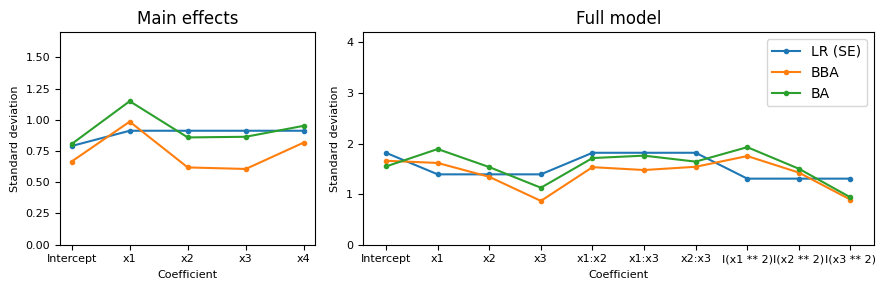

In [19]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(9, 3), width_ratios=[1, 2])

std_main = std_results_main[['Intercept', 'x1', 'x2', 'x3', 'x4']]
ax = plot_std_coefficients(std_main.loc[0], std_main.loc[1], 
                      std_main.loc[2], ax=axes[0])
ax.set_title('Main effects')
ax.get_legend().remove()
ax.set_ylim(0, 1.7)

std_full = std_results_full[['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 
                             'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']]
ax = plot_std_coefficients(std_full.loc[0], std_full.loc[1], 
                      std_full.loc[2], ax=axes[1])
ax.set_title('Full model')
ax.legend()
ax.set_ylim(0, 4.2)
plt.tight_layout()

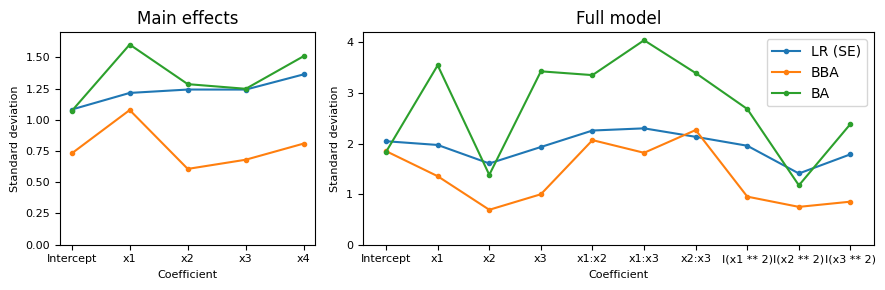

In [20]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(9, 3), width_ratios=[1, 2])

std_main = std_results_main[['Intercept', 'x1', 'x2', 'x3', 'x4']]
ax = plot_std_coefficients(std_main.loc[3], std_main.loc[4], 
                      std_main.loc[5], ax=axes[0])
ax.set_title('Main effects')
ax.get_legend().remove()
ax.set_ylim(0, 1.7)

std_full = std_results_full[['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 
                             'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']]
ax = plot_std_coefficients(std_full.loc[3], std_full.loc[4], 
                      std_full.loc[5], ax=axes[1])
ax.set_title('Full model')
ax.set_ylim(0, 4.2)

ax.legend()
plt.tight_layout()